In [1]:
!nvidia-smi

Wed Nov 19 15:26:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import libraries

In [3]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 432 (delta 47), reused 53 (delta 24), pack-reused 351 (from 1)
Receiving objects: 100% (432/432), 171.19 KiB | 5.19 MiB/s, done.
Resolving deltas: 100% (275/275), done.


In [4]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Nov 19 15:27 configs
drwxr-xr-x 2 root root 4096 Nov 19 15:27 datasets
drwxr-xr-x 2 root root 4096 Nov 19 15:27 notebooks
-rw-r--r-- 1 root root  315 Nov 19 15:27 README.md
-rw-r--r-- 1 root root   93 Nov 19 15:27 requirements.txt
drwxr-xr-x 4 root root 4096 Nov 19 15:27 src
drwxr-xr-x 2 root root 4096 Nov 19 15:27 tests


In [5]:
!pip -q install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.6 MB/s eta 0:00:00:00:0100:01


In [6]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods

import medmnist
from medmnist import INFO, Evaluator

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

## Config

In [7]:
run_name = "run001"

LR = 2e-4
WD = 1e-4

EPOCHS = 100
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cuda


## Datasets

In [8]:
data_flag = 'pathmnist'
download=True

info = INFO[data_flag]
task = info['task']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])
print(f"Dataset: {data_flag}, Task: {task}, Num classes: {n_classes}")

Dataset: pathmnist, Task: multi-class, Num classes: 9


In [9]:
class DS(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rows = self.df.iloc[idx]
        path, y = rows["image"], rows["labels"]
        img = Image.open(path).convert("RGB")

        return self.transform(img), y

In [10]:
# Transform
train_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

test_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [11]:
def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)
    labels = torch.from_numpy(np.array(labels)).long().view(-1)
    return imgs, labels

train_dataset = DataClass(split='train', transform=train_transform, download=download)
valid_dataset   = DataClass(split='val',   transform=test_transform, download=download)
test_dataset  = DataClass(split='test',  transform=test_transform, download=download)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)

len(train_loader), len(valid_loader), len(test_loader)

100%|██████████| 206M/206M [03:23<00:00, 1.01MB/s] 


(1407, 157, 113)

In [12]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Explain

In [15]:
model_name = "vit_tiny_patch16_224"
checkpoint_path = "/kaggle/input/ex-lavit/pytorch/default/3/linear_vit_tiny_pathmnist.pth"

model = create_linear_attention_vit(
    model_name,
    pretrained=False,
    num_classes=n_classes
)

load_checkpoint(
    checkpoint_path,
    model,
    device=DEVICE
)

model.to(DEVICE).eval()

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: False
    Classes: 9
    Image size: 224
    Original parameters: 5,526,153
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,526,153
    Trainable parameters: 5,526,153


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [16]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [17]:
idx = np.random.randint(len(test_dataset))

x, y_true = test_dataset[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [18]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [19]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.2691, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.2312, device='cuda:0', grad_fn=<MeanBackward0>))

### GradCAM

In [20]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [21]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.8487, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.5223, device='cuda:0', grad_fn=<MeanBackward0>))

### Integrated Gradients

In [22]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [23]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.2762, device='cuda:0'),
 tensor(0.0942, device='cuda:0'))

### Rollout

In [24]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [25]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1747, device='cuda:0'),
 tensor(0.1393, device='cuda:0'))

## Visualization

5191


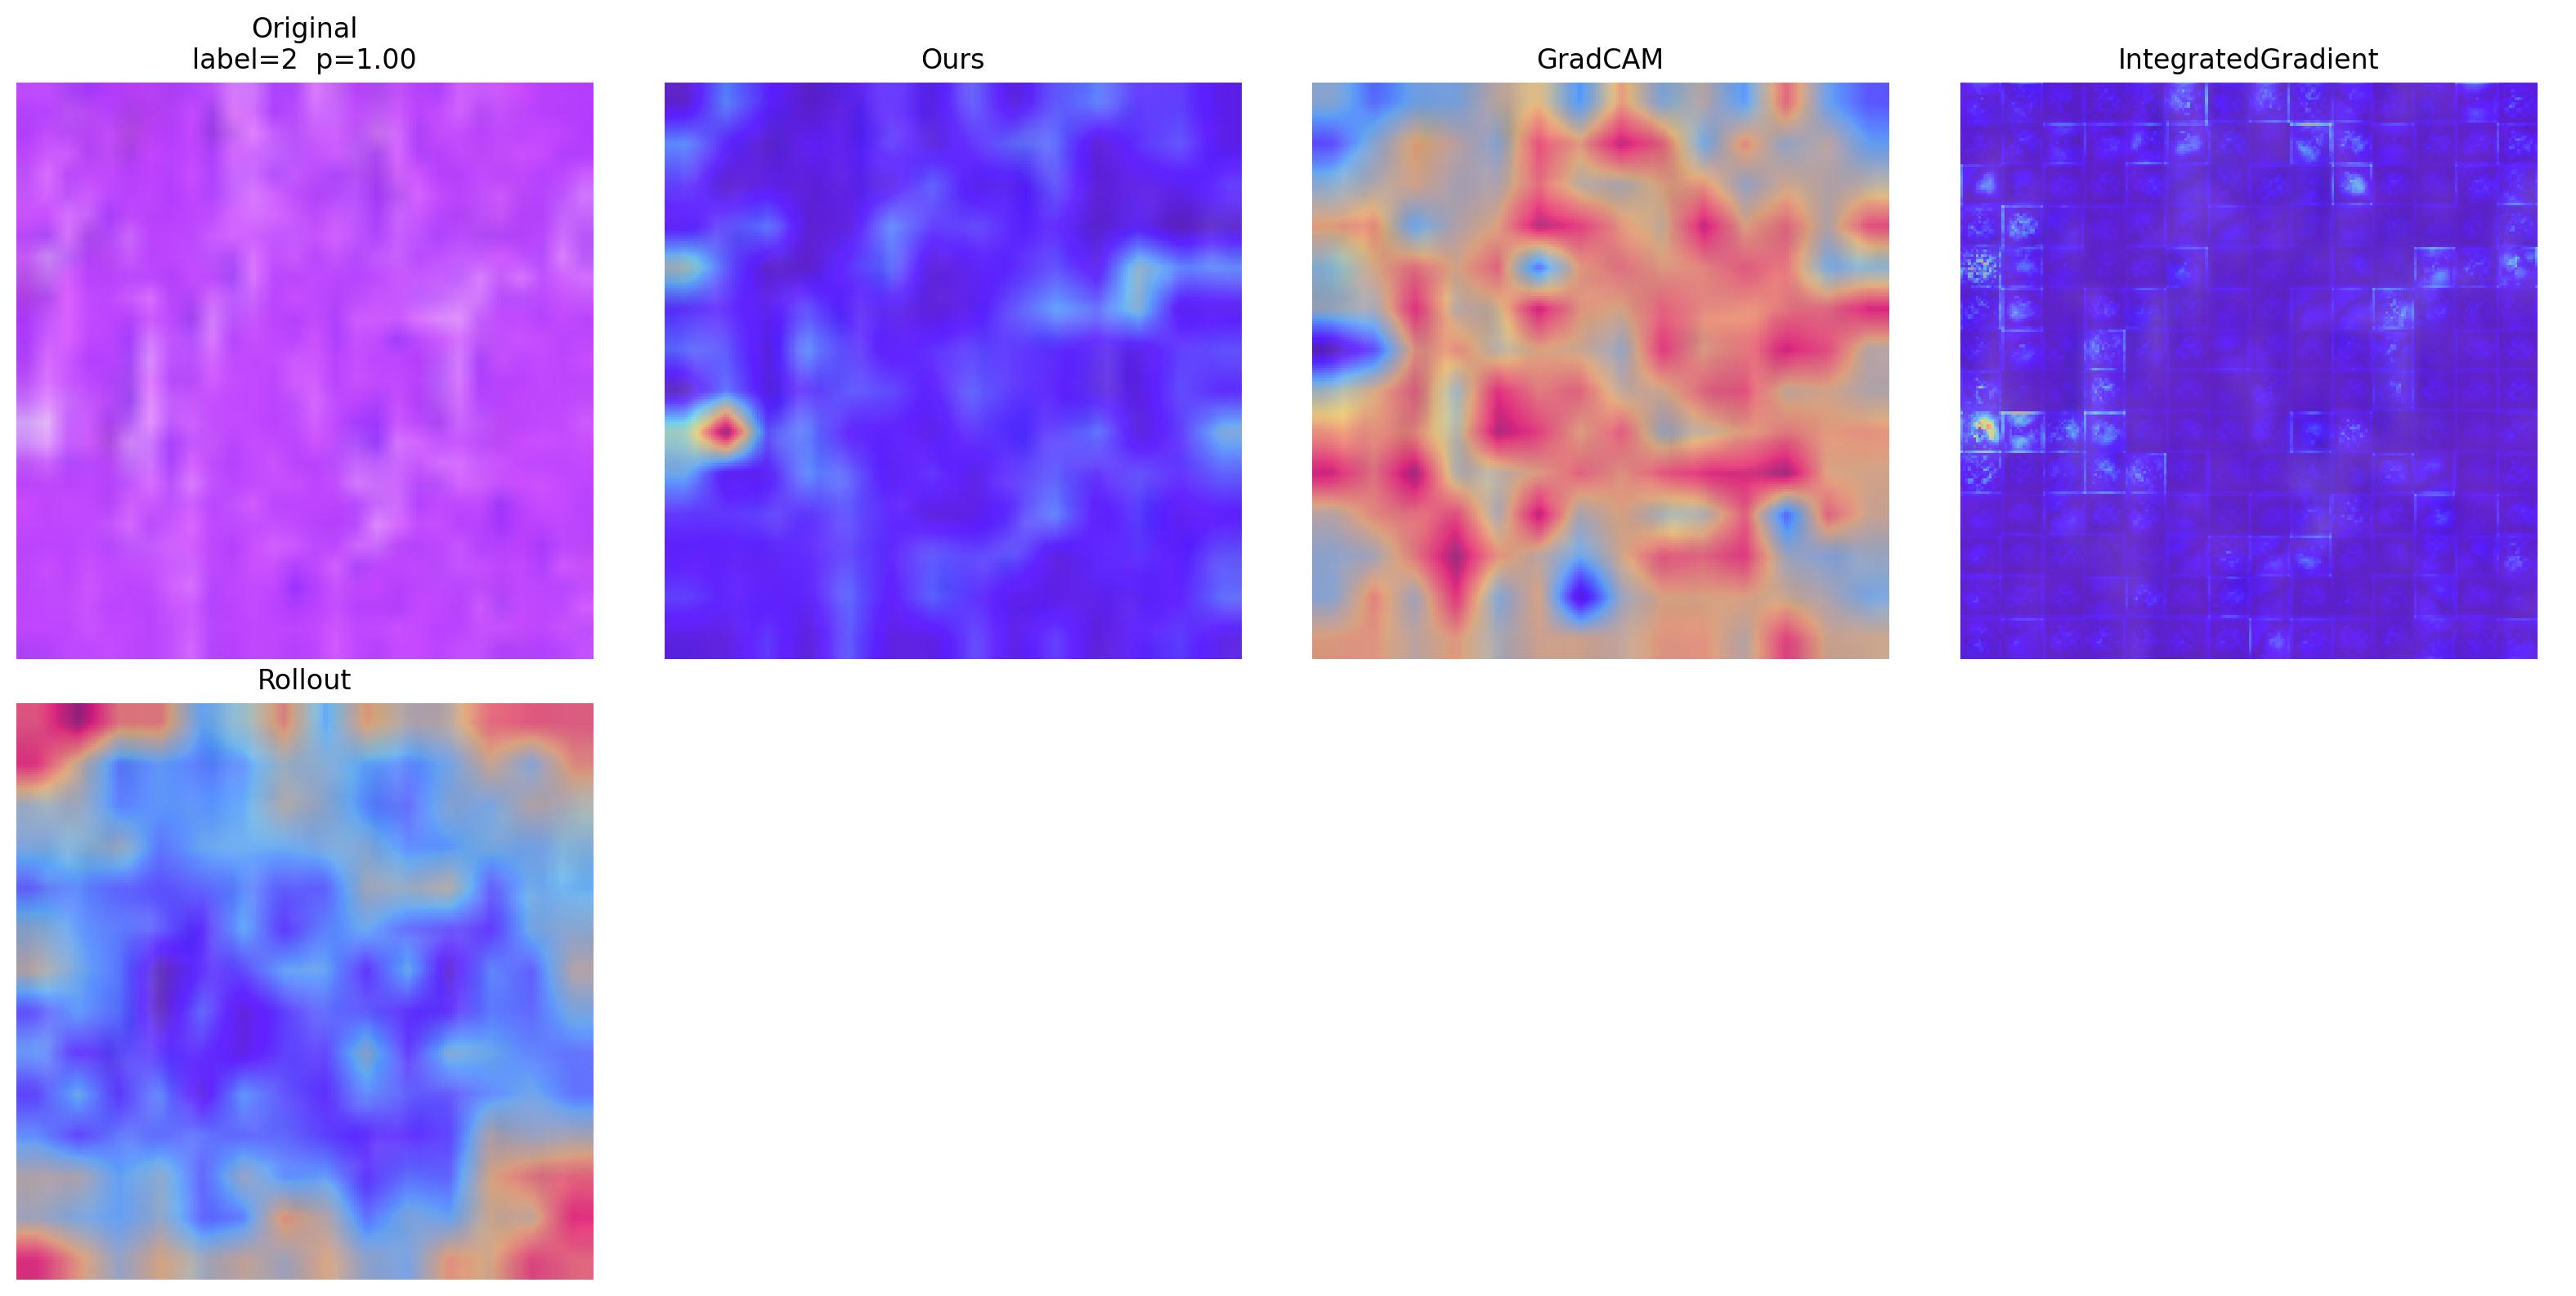

In [28]:
idx = np.random.randint(len(test_dataset))
print(idx)

_ = visualize_methods(
    test_dataset, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [ ]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        use_pred=True,
        max_samples=1080,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        max_samples=1080,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
Results for Ours: {'auc_del_mean': 0.2871675495328041, 'auc_ins_mean': 0.5751447854958436, 'entropy_mean': 0.9374887443506713, 'gini_mean': 0.990029213624075, 'n_samples': 10, 'cosine_cs_mean': 0.12106450037099421, 'cosine_cs_std': 0.2772906754196085}
--------------------------------------------------
Evaluating GradCAM...
Results for GradCAM: {'auc_del_mean': 0.44314474108008295, 'auc_ins_mean': 0.4186336180149336, 'entropy_mean': 0.9986877926330978, 'gini_mean': 0.9948295370675624, 'n_samples': 10, 'cosine_cs_mean': 0.22922373116016387, 'cosine_cs_std': 0.24386262056159325}
--------------------------------------------------
Evaluating IG...
Results for IG: {'auc_del_mean': 0.36120787447117386, 'auc_ins_mean': 0.5263576846632896, 'entropy_mean': 0.9701806148396812, 'gini_mean': 0.9929921514354646, 'n_samples': 10, 'cosine_cs_mean': 0.5835147649049759, 'cosine_cs_std': 0.12853435350742548}
--------------------------------------------------
Evaluating Rollout...
Resul

In [30]:
results

{'Ours': {'auc_del_mean': 0.2871675495328041,
  'auc_ins_mean': 0.5751447854958436,
  'entropy_mean': 0.9374887443506713,
  'gini_mean': 0.990029213624075,
  'n_samples': 10,
  'cosine_cs_mean': 0.12106450037099421,
  'cosine_cs_std': 0.2772906754196085},
 'GradCAM': {'auc_del_mean': 0.44314474108008295,
  'auc_ins_mean': 0.4186336180149336,
  'entropy_mean': 0.9986877926330978,
  'gini_mean': 0.9948295370675624,
  'n_samples': 10,
  'cosine_cs_mean': 0.22922373116016387,
  'cosine_cs_std': 0.24386262056159325},
 'IG': {'auc_del_mean': 0.36120787447117386,
  'auc_ins_mean': 0.5263576846632896,
  'entropy_mean': 0.9701806148396812,
  'gini_mean': 0.9929921514354646,
  'n_samples': 10,
  'cosine_cs_mean': 0.5835147649049759,
  'cosine_cs_std': 0.12853435350742548},
 'Rollout': {'auc_del_mean': 0.35056221823739986,
  'auc_ins_mean': 0.5108426294020416,
  'entropy_mean': 0.9572813025868122,
  'gini_mean': 0.9923233138862997,
  'n_samples': 10,
  'cosine_cs_mean': 1.000000035762787,
  'cosi